## **5.2 합성곱 신경망 맛보기**

구글 코랩 링크
https://drive.google.com/file/d/1Gcv18mXP1iRIrTolB6E3adf1iK3N4VQT/view?usp=sharing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn

from torch.autograd import Variable
# Variable (변수): 과거 PyTorch(0.4.0 이전 버전)에서 자동 미분을 수행하기 위해 텐서(Tensor)를 감싸던 클래스입니다.
# 참고사항: 현재 최신 PyTorch 버전에서는 Variable이 torch.Tensor에 완전히 통합되었습니다.
# 즉, 요즘에는 이 라인을 임포트할 필요 없이 그냥 일반 torch.Tensor를 쓰셔도 자동으로 미분이 지원됩니다. (레거시 코드 분석을 위해 남아있는 경우가 많습니다.)

import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
# Dataset: 내가 가진 데이터(이미지, 주파 기록, 텍스트 등)를 어떻게 읽어오고 정답(Label)과 매핑할지 정의
# DataLoader: 정의된 Dataset을 입력받아 데이터를 미니배치(Mini-batch) 단위로 쪼개고, 데이터를 무작위로 섞어주는(Shuffle) 등 학습 루프에 데이터를 주입하는 역할

In [2]:
print("PyTorch 버전:", torch.__version__)
print("Torchvision 버전:", torchvision.__version__)

print("CUDA(GPU) 사용 가능 여부:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("사용 중인 GPU:", torch.cuda.get_device_name(0))

PyTorch 버전: 1.13.1
Torchvision 버전: 0.14.1
CUDA(GPU) 사용 가능 여부: False


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# 일반적으로 하나의 GPU를 이용할 때는,
# model = Net()
# model.to(device)

# 를 하는데, 다수의 GPU를 이용한다면 아래와 같이 코드를 작성

# model = Net()
# if torch.cuda.device_count() > 1:
#  model = nn.DataParallel(net)
# model.to(device)


cpu


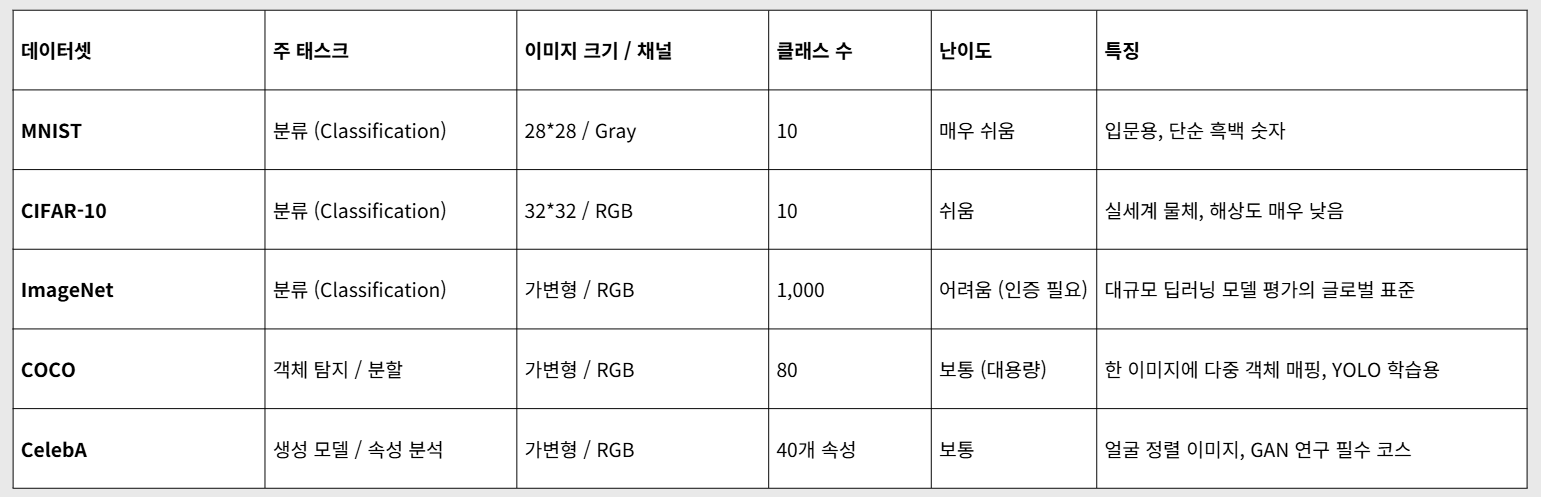




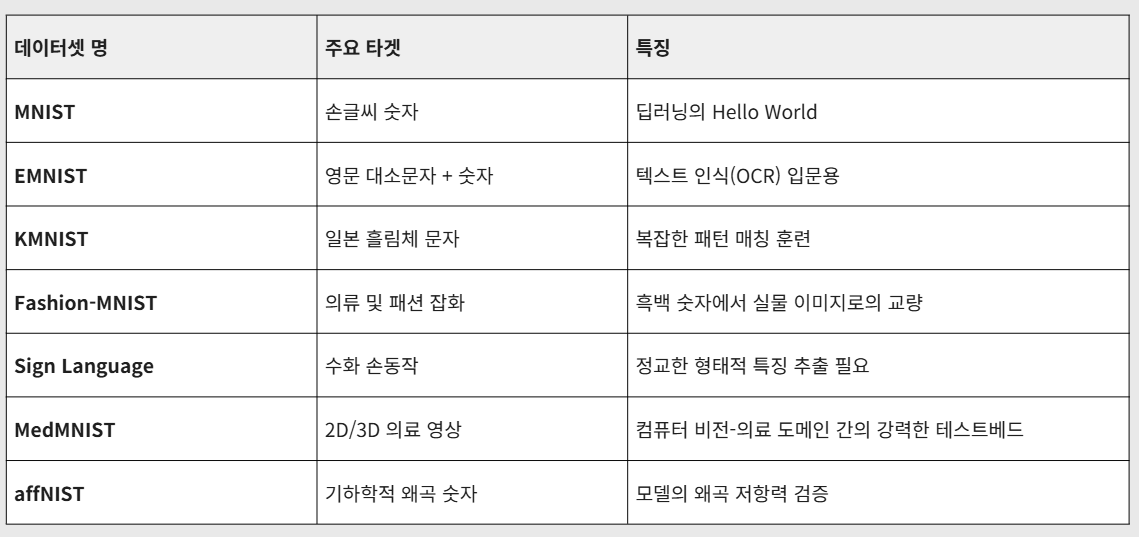

In [4]:
train_dataset  = torchvision.datasets.FashionMNIST("FashionMNIST/", download=True, transform=
                                                transforms.Compose([transforms.ToTensor()]))

# torchvision.datasets는 다양한 데이터셋을 포함(CIFAR, COCO, MNIST, ImageNet 등)

# 첫번째 인자 : 현재 실행 중인 위치에 FashionMNIST라는 이름의 폴더를 만들고, 그 안에 데이터를 저장하라는 뜻입니다.
# 코랩에서는 가상컴퓨터상에서 /content 위치에서 파이썬이 실행됨
# download 인자 : 그 폴더에 데이터가 없으면 자동으로 다운로드한다는 의미

# transform은 가져온 이미지 파일을 딥러닝에 사용하기 좋게 변환하는 것
# transforms.Compose([...]): 여러 개의 전처리 단계를 하나로 묶어(체인처럼 연결) 차례대로 실행해 주는 도구
# 현재는 transforms.ToTensor() 하나만 묶여 있습니다.
# transforms.ToTensor(): 매우 중요한 변환 도구입니다. 원본 이미지(보통 0~255 사이의 픽셀 값을 가진 PIL 이미지나 넘파이 배열)를
# PyTorch 텐서(Tensor) 데이터 구조로 변환하면서, 동시에 픽셀 값을 0.0 ~ 1.0 사이의 실수값으로 정규화(Normalization)해 줍니다.
# 딥러닝 모델은 입력값이 0과 1 사이에 있을 때 가장 안정적으로 학습하기 때문에 필수적인 단계입니다.

test_dataset  = torchvision.datasets.FashionMNIST("FashionMNIST/", download=True, train=False, transform=
                                               transforms.Compose([transforms.ToTensor()]))
# train 인자 : train을 False로 하면 test용 데이터를 다운로드 하게 됨, 인자 생략시 train용 다운로드





In [5]:
print("transform 하고 불러왔을때 타입 :",type(train_dataset))
print("transform 하고 불러왔을때 기본 형태 :",(train_dataset))


sample_data = train_dataset[0]
print("1. 데이터의 타입:", type(sample_data)) # tuple 출력됨
print("2. 데이터의 크기:", len(sample_data))

print(sample_data[0], sample_data[1])
print(type(sample_data[0]))

print(sample_data[0].shape)



transform 하고 불러왔을때 타입 : <class 'torchvision.datasets.mnist.FashionMNIST'>
transform 하고 불러왔을때 기본 형태 : Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: FashionMNIST/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
1. 데이터의 타입: <class 'tuple'>
2. 데이터의 크기: 2
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0

In [6]:
temp = torchvision.datasets.FashionMNIST("FashionMNIST_temp/", download=True)


print("transform 없이 불러왔을때 타입 :", type(temp))
print("transform 없이 불러왔을때 기본 형태 :", temp)

print(type(temp[0]))

print(len(temp[0]))


print(temp[0][0], temp[0][1])
print(temp[1][0], temp[1][1])
print(temp[2][0], temp[2][1])

print(temp[0][0].size)

transform 없이 불러왔을때 타입 : <class 'torchvision.datasets.mnist.FashionMNIST'>
transform 없이 불러왔을때 기본 형태 : Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: FashionMNIST_temp/
    Split: Train
<class 'tuple'>
2
<PIL.Image.Image image mode=L size=28x28 at 0x1301C0370> 9
<PIL.Image.Image image mode=L size=28x28 at 0x132217430> 0
<PIL.Image.Image image mode=L size=28x28 at 0x1301C0370> 0
(28, 28)


In [7]:
import os

# 현재 작업 디렉토리 출력
print("현재 경로:", os.getcwd())

# 현재 경로에 있는 파일/폴더 리스트 출력
print("폴더 내 파일 목록:", os.listdir('.'))

현재 경로: /Users/namun/dev/A7608-2026-1-vision-dl/chap05
폴더 내 파일 목록: ['5-2. 합성곱 신경망 맛보기 발표.ipynb', 'python_5장(추가실습)_RandomResizedCrop.ipynb', 'FashionMNIST', 'python_5장.ipynb', 'colab_5장(추가실습)_RandomResizedCrop.ipynb', 'FashionMNIST_temp', 'data', 'colab_5장.ipynb']


In [8]:
# 1. 원하는 시드 번호 설정 (예: 42)
seed_number = 42

# 2. 파이썬 및 주요 라이브러리 시드 고정
random.seed(seed_number)
np.random.seed(seed_number)

# 3. PyTorch 시드 고정 (CPU 및 GPU 모두 고정)
torch.manual_seed(seed_number)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_number)
    torch.cuda.manual_seed_all(seed_number)  # 멀티 GPU 사용 시

# 4. PyTorch 연산의 결정론적(Deterministic) 실행 설정
# (속도가 미세하게 느려질 수 있으나 실험 재현성을 완벽히 확보해 줍니다)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
# DataLoader 데이터를 100개 단위로 묶어서 불러올수 있도록 하는 것. 100개 단위로 묶어둠
# 보통, Loader는 묶는 것과, 셔플 옵션을 주는 것

# train_loader는 shuffle 옵션을 True로 두는 것이 좋다. 0~500번까지 티셔츠, 501~1000까지 양말 이런식으로 데이터 구성되어있을 수 있음
# 다만, 재현성을 생각해서 시드값을 고정해두는 것이 바람직
# test 데이터는 최종적으로 평가용으로만 쓰는 것이기에 순서가 중요하지 않아 셔플하지 않아도 됨


# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True)


test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=100)

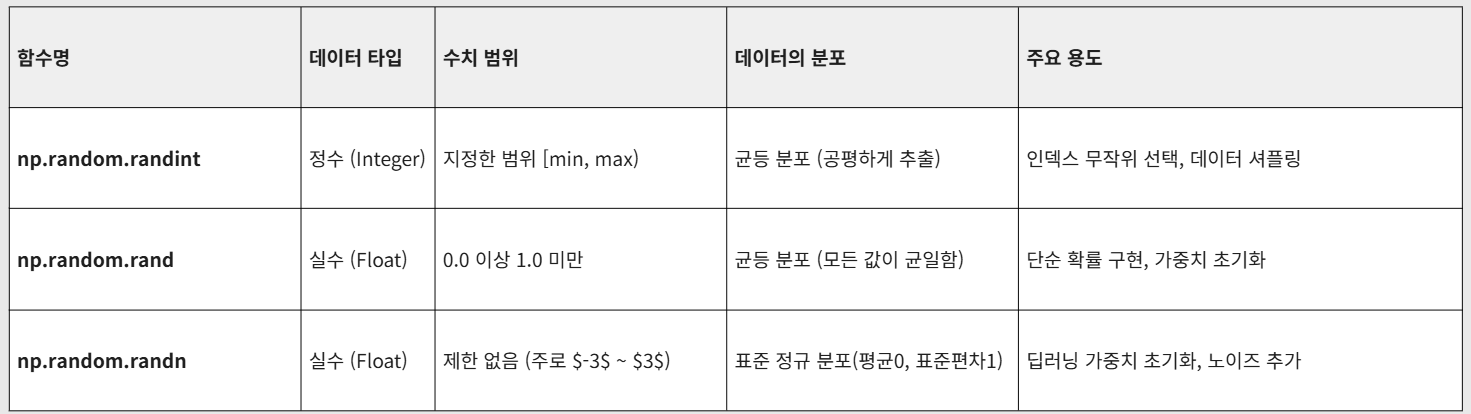

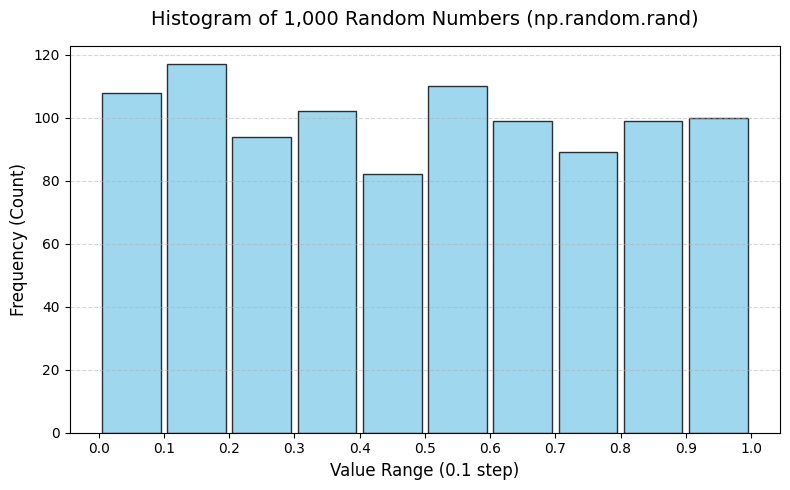

In [10]:


# 참고로 책에는 rand(8)이 0~1사이의 정규분포를 따른다고 되어있는데
# 잘못된 내용/ 0~1사이의 균등분포를 나타내 줌

# 1. np.random.rand를 사용하여 1,000개의 난수 생성 (0.0 이상 1.0 미만)
data = np.random.rand(1000)

# 2. 0.1 단위로 구간(Bins) 설정
# np.arange(0.0, 1.1, 0.1) -> [0.0, 0.1, 0.2, 0.3, ..., 1.0]
bins = np.arange(0.0, 1.1, 0.1)

# 3. 그래프 그리기 (가독성을 위해 스타일 지정)
fig, ax = plt.subplots(figsize=(8, 5))

# hist 함수 옵션 설명:
# - bins: 데이터를 나눌 구간 좌표 목록
# - edgecolor: 막대 테두리 색상 (구간을 명확히 구분하기 위함)
# - rwidth: 막대 사이의 살짝의 간격 (0.9로 주어 막대끼리 달라붙지 않게 조절)
ax.hist(data, bins=bins, edgecolor='black', color='skyblue', alpha=0.8, rwidth=0.9)

# 4. 축 눈금 및 라벨 설정
ax.set_title('Histogram of 1,000 Random Numbers (np.random.rand)', fontsize=14, pad=15)
ax.set_xlabel('Value Range (0.1 step)', fontsize=12)
ax.set_ylabel('Frequency (Count)', fontsize=12)
ax.set_xticks(bins) # x축 눈금을 0.1 단위로 촘촘하게 표시

# 5. 격자(Grid)선 추가로 가독성 높이기
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 이미지 저장 및 출력
plt.tight_layout()

In [11]:
img, label = train_dataset[0]

# 2. 이미지의 형태(Shape) 출력 // 이미지와 레이블로 구분되어 튜플 형태로 저장되어 있음
#print("이미지 데이터의 형태(Shape):", img.shape)
print("이미지 크기(W, H):", img.size)

print("정답 레이블 데이터:", label)

이미지 크기(W, H): <built-in method size of Tensor object at 0x1322d4ea0>
정답 레이블 데이터: 9


In [12]:
# 책에서는 바로 label을 직접 mapping했지만, train_dataset에는 class 메소드로 클래스 이름을 이미 알려주고 있음
#labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt',
#              7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'}


# 1. 클래스 이름(설명서) 바로 꺼내 쓰기
print(train_dataset.classes)
# 출력: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. 번호와 텍스트 매핑 사전 만들기
labels_map = {i: class_name for i, class_name in enumerate(train_dataset.classes)}
print(labels_map)
# 출력: {0: 'T-shirt/top', 1: 'Trouser', ..., 9: 'Ankle boot'}


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


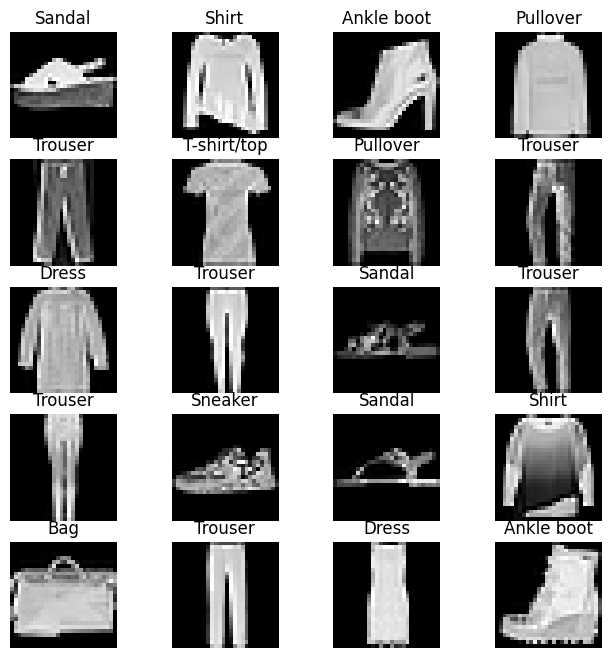

In [13]:
fig = plt.figure(figsize=(8,8));
columns = 4;
rows = 5;

# 8*8인치 크기의 표를 만드는데, 5행 4열 크기로 할 것


# i는 1~20까지의 intㅊ
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset));
    img = train_dataset[img_xy][0][0,:,:]
# 랜덤 int 값으로 데이터셋 하나를 가져와서 [0]은 이미지를 가져오겠다는 것이고([1]은 정답 레이블)
# [0,:,:]은 이미지가 torch.Size([1, 28, 28]) 형태로 되어있는데, 그 중에서 채널은 gray 단일이므로 28*28형태의 이미지로 가져온다는 의미

    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    #[1]은 정답 레이블이므로 타이틀로 정답을 표시하겠다는 의미

    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

In [14]:
# PyTorch에서 인공신경망 모델을 만들 때는 반드시 nn.Module을 상속받아야 합니다.

class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN,self).__init__()
        # 부모 클래스인 nn.Module의 생성자를 호출하여 모델을 초기화합니다.

        # fully connected한 선형 회귀모델을 만듦. 입력은 28*28인 784 크기이면서 256특성으로 압축하게 됨
        self.fc1 = nn.Linear(in_features=784,out_features=256)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=256,out_features=128)
        self.fc3 = nn.Linear(in_features=128,out_features=10)

# 모델이 학습데이터 받아서 순전파 연산 하는 것
    def forward(self, input_data):
            # 2D 이미지를 1D(784 크기)로 일렬로 쭉 펼침, numpy의 reshape의 역할
        out = input_data.view(-1, 784)

            # fc1 통과 후 활성화 함수(ReLU) 적용
        out = F.relu(self.fc1(out))

            # 선형 레이어 뒤이므로 일반 Dropout으로 규칙적으로 억제
        out = self.drop(out)

            # fc2 통과 후 활성화 함수 적용
        out = F.relu(self.fc2(out))

            # 최종 출력층 통과
        out = self.fc3(out)
        return out

In [15]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

# 손실 함수(Loss Function / Criterion) 정의
# 모델의 예측값과 실제 정답(Label) 사이의 오차를 계산하는 기준
# nn.CrossEntropyLoss는 다중 분류(Multi-class Classification) 문제의 표준 오차 함수이며,
# 내부적으로 Softmax 연산과 Cross Entropy 연산을 한 번에 안전하게 수행해 줍니다.
criterion = nn.CrossEntropyLoss();

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
num_epochs = 5          # 전체 데이터셋을 총 몇 번 반복해서 학습할지 결정 (5회)
count = 0               # 몇 번의 가중치 업데이트(Iteration)가 일어났는지 기록하는 카운터
loss_list = []          # 그래프를 그리기 위해 오차(Loss) 값을 저장할 리스트
iteration_list = []     # 그래프를 그리기 위해 이터레이션 횟수를 저장할 리스트
accuracy_list = []      # 그래프를 그리기 위해 정확도(Accuracy) 값을 저장할 리스트

predictions_list = []   # 모델의 모든 예측값을 누적 보관할 리스트
labels_list = []        # 모든 실제 정답 레이블을 누적 보관할 리스트

for epoch in range(num_epochs):
    for images, labels in train_loader:

      # GPU 연산을 위해 이미지와 정답 데이터를 GPU(또는 설정된 장치)로 전송합니다.
        images, labels = images.to(device), labels.to(device)


    # 과거 PyTorch 버전에서 쓰이던 Tensor를 Variable 객체로 감싸는 코드입니다.
    # 과거에는 기본 Tensor는 숫자 행렬이었고, 학습용 데이터(미분할수 있게)는 Variable로 감싸주어야만 제대로 학습시킬수 있었는데
    # 지금은 Tensor 자체가 Variable의 특성을 내장하고 있기 때문에 안써도 됨
    # 이미지 데이터를 [100, 1, 28, 28] 크기로 한 번 더 명시적으로 변형

        #train = Variable(images.view(100, 1, 28, 28))
        train = images.view(100, 1, 28, 28)

        # labels = Variable(labels)
        labels

        outputs = model(train)                  # 1) 모델에 데이터를 입력하여 예측값(outputs) 획득
        loss = criterion(outputs, labels)       # 2) 예측값과 실제 정답을 손실함수에 넣어 오차(Loss) 계산
        optimizer.zero_grad()                   # 3) 이전 단계에서 계산되어 남은 가중치 기울기(Gradient)들을 0으로 초기화   // 역전파 과정에서 나온 순수 미분값
        loss.backward()                         # 4) 오차를 바탕으로 가역 방향으로 미분하여 가중치별 기울기 계산 (역전파)  // 얼마나 가중치들을 업데이트 해야 할지 기울기 계산
        optimizer.step()                        # 5) 계산된 기울기 방향으로 가중치들을 한 걸음 업데이트 (Adam 알고리즘 실행)
                                                #    optimizer 내부에 state 형태로 이전 기울기 정보가 반영된 모멘텀(방향, 속도)은 가지고 있다.

        count += 1

    # 50으로 나눈 나머지는 0~49인데, 0일때만 False이고, not으로 True가 되므로 50번에 한번씩 아래 코드 실행됨
        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:

              # 50카운트마다 매번, 테스트용 데이터를 device로 보내는 것은 CPU대역폭을 이용해야 하므로 비효율적이고
              # GPU에 한번만 올려두고 계속 쓰면 더 빠를수 있음
              # 단, 일반적인 상황에서 GPU VRAM에 한계가 있어서 OOM 에러가 날 수 있기 때문에 매번 불러오는 식으로 함
                images, labels = images.to(device), labels.to(device)

                labels_list.append(labels)
                # test = Variable(images.view(100, 1, 28, 28))
                test = images.view(100, 1, 28, 28)
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total

            #loss.data는 오래된 방식으로, 메모리누수 문제 및 에러 발생 가능성이 있어 사용 지양해야 함
            #같은 기능으로 loss.item()을 쓰면 더 바람직함
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)


        # 500카운트당 한번씩 모델 성능 표출
        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4026358425617218, Accuracy: 82.02999877929688%
Iteration: 1000, Loss: 0.5056381821632385, Accuracy: 84.81999969482422%
Iteration: 1500, Loss: 0.4073079824447632, Accuracy: 85.4000015258789%
Iteration: 2000, Loss: 0.3829174041748047, Accuracy: 85.58999633789062%
Iteration: 2500, Loss: 0.19865506887435913, Accuracy: 86.19000244140625%
Iteration: 3000, Loss: 0.2979585528373718, Accuracy: 86.6500015258789%


In [17]:
# loss_list.append(loss.data)
# loss.data : 과거에 쓰던 "포장지만 남겨둔 텐서" (사용 자제 권장)
# loss.data는 아주 옛날 파이토치 버전(0.4.0 이전)에서 주로 쓰던 방식입니다.
# 역할: 역전파(Backpropagation) 계산용 히스토리(미분 그래프 정보)는 끊어버리고, 오직 숫자 데이터만 담고 있는 "또 다른 텐서 객체"를 반환합니다.
# 단점: 여전히 텐서이기 때문에, 이를 리스트에 계속 누적하면 포장지(Tensor 객체 껍데기)들이 GPU VRAM 메모리를 찔끔찔끔 계속 잡아먹게 됩니다.
# * 게다가 파이토치 공식 문서에서도 loss.data는 예기치 못한 미분 에러를 만들 수 있어 사용하지 말 것(Deprecated)을 강력히 권장하고 있습니다.



#loss : 미분 엔진과 GPU 정보가 주렁주렁 달린 무거운 텐서 박스  -- gpu VRAM에 위치
#loss.data : 미분 엔진만 떼어낸 가벼운 텐서 박스 (여전히 박스 형태) -- gpu VRAM에 위치
#loss.item() : 박스를 완전히 버리고 알맹이만 쏙 빼낸 순수한 숫자  -- cpu RAM에 위치

In [18]:
dnn_loss_list = [loss.cpu().item() for loss in loss_list]
dnn_accuracy_list = [acc.cpu().item() if hasattr(acc, 'cpu') else acc for acc in accuracy_list]
dnn_iteration_list = iteration_list[:] # iteration 횟수는 원래 파이썬 정수라 그대로 복사해도 됨

# .cpu(): GPU 메모리에 있는 텐서를 컴퓨터의 기본 CPU 메인 메모리로 복사해 데려옵니다.
# .item(): 텐서 형태(tensor(0.245))로 감싸져 있는 껍데기를 깨고 내부의 순수한 파이썬 실수값(0.245)만 알맹이로 꺼내줍니다.
# tensor.data를 리스트에 append 했기 때문에, 데이터는 여전에 gpu에 있는 상태라, 직접적으로 matplotlib 등으로 접근하면 메모리 에러가 발생


#만약에 loss.item()으로 애초에 저장 했다면 이미 데이터가 cpu 단의 메모리로 이동한 상황
#dnn_loss_list = loss_list[:]
#dnn_accuracy_list = accuracy_list[:]
#dnn_iteration_list = iteration_list[:]

교과서에서는 Accuracy를 만 썼을때의 주의 사항에 대해서 설명 // 특히 클래스 불균형 상태 일때

전체 정확도(Global Accuracy)는 클래스 불균형(Class Imbalance) 데이터셋에서 모델의 왜곡된 성능을 보여줄 위험이 있습니다. 이는 각 클래스별 세부 성능을 반영하지 못하고 전체적인 정답 확률만 나타내기 때문입니다. 따라서 보다 객관적인 평가를 위해서는 '클래스별 정확도(Per-class Accuracy)'를 개별적으로 확인하거나, 이를 평균 내어 평가하는 '매크로 평균 정확도(Macro-averaged Accuracy)' 등의 지표를 함께 도입하는 것이 바람직합니다

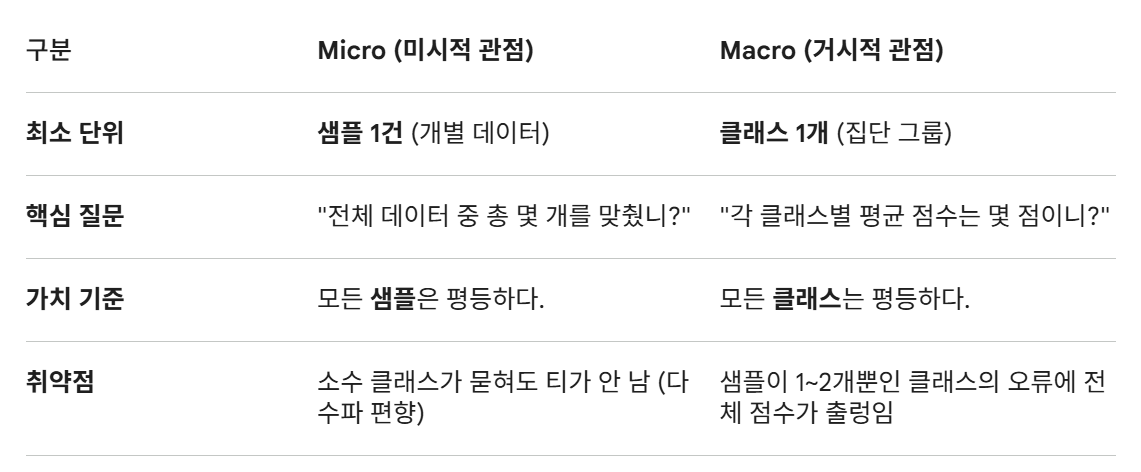

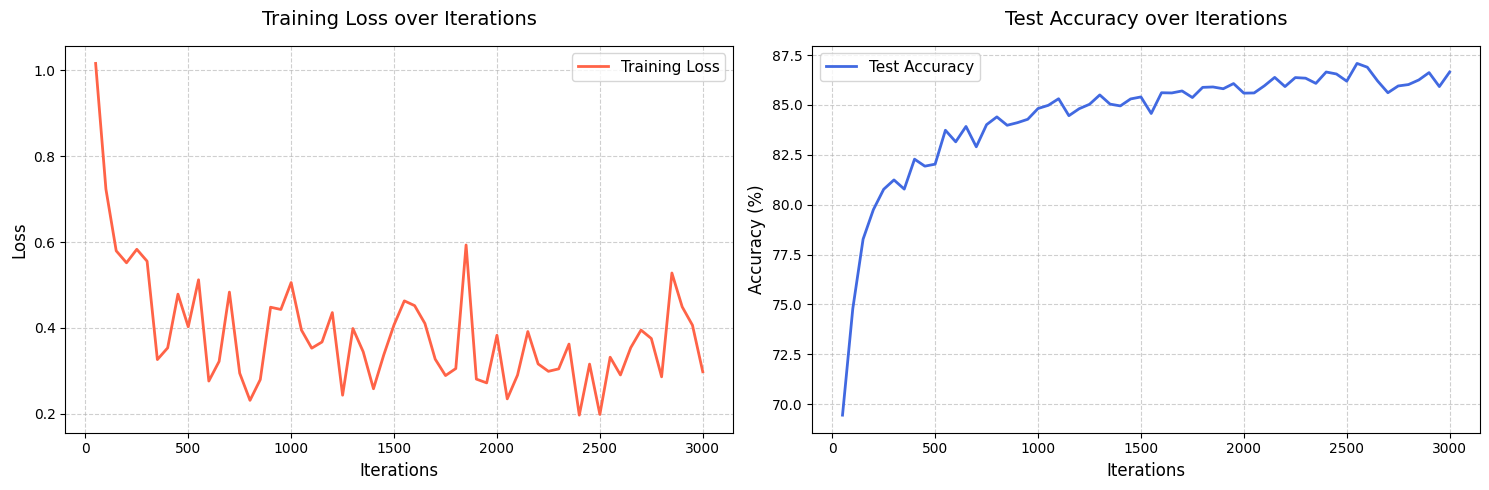

In [19]:
#count50마다 정확도나 손실 값을 리스트에 넣어서 저장하고 있는데,
#실제로 print하는 것은 count 500 단위로 불필요한 저장을 하고 있는 셈
#(아마도) 촘촘한 형태로 그래프를 그려서 보여주기 위한 의도로 보이는데
#그래프를 그려주는 항목이 생략된 것으로 보임


# 1. GPU에 올라가 있는 텐서 데이터를 CPU 및 넘파이 배열로 변환하는 작업이 필요합니다.
# (PyTorch 텐서 리스트를 matplotlib이 직접 그릴 수 없기 때문에 .cpu() 또는 .item() 처리가 필요합니다.)
cleaned_loss = [loss.cpu().item() if hasattr(loss, 'cpu') else loss for loss in loss_list]
cleaned_accuracy = [acc.cpu().item() if hasattr(acc, 'cpu') else acc for acc in accuracy_list]

# 2. 가로로 긴 1행 2열짜리 서브플롯(Subplot) 영역 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- 왼쪽 그래프: 손실(Loss) 변화 추이 ---
ax1.plot(iteration_list, cleaned_loss, color='tomato', label='Training Loss', linewidth=2)
ax1.set_title('Training Loss over Iterations', fontsize=14, pad=15)
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# --- 오른쪽 그래프: 정확도(Accuracy) 변화 추이 ---
ax2.plot(iteration_list, cleaned_accuracy, color='royalblue', label='Test Accuracy', linewidth=2)
ax2.set_title('Test Accuracy over Iterations', fontsize=14, pad=15)
ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

# 3. 레이아웃 다듬기 및 출력
plt.tight_layout()
plt.show()

In [20]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        #여거래의 계층을 가독성 있게 구성해주는 역할
        self.layer1 = nn.Sequential(

           # 흑백 단일 채널이므로 in은 1이고, kernel은 학습의 대상이 됨, stride는 별도로 설정하지 않아서 1로 기본
           # 패딩(padding=1)을 주어 컨볼루션 연산 후에도 가로/세로 크기가 유지되도록 합니다. (28x28 유지)
           # stride의 기본값은 1으로 지정
           # 형태 : 1 28 28
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
           # 형태 : 32 28 28

           # 배치 정규화: 32개 특징 맵의 값을 평균 0, 분산 1로 정규화하여 학습 속도를 올리고 오버피팅을 방지합니다.
            nn.BatchNorm2d(32),

            nn.ReLU(),
            #맥스풀링으로 이미지의 크기는 가로세로 각각 1/2이 됨
           # 커널사이즈를 2라고만 지정하면 2*2 형태로 이해
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 형태 : 32 14 14

        )
        self.layer2 = nn.Sequential(

            # 여기서, 패딩이 적용되지 않았다는 것에 주의, 끝단의 2 픽셀이 깍여나감
            # 형태 : 32 14 14
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            # 형태 : 64 12 12
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)
            #그냥 2만 입력하면 커널사이즈는 2가 되고, stride는 자동으로 kernel_size와 같은 값으로 입력함
            nn.MaxPool2d(2)

            # 형태 : 64 6 6
        )
        # 형태 : 64 6 6
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)

        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)


    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)

        #tensor에서 view는 reshape역할
        out = out.view(out.size(0), -1)

        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

BatchNorm2d는 이미지의 피쳐맵을 강제로 평균 0, 분산1로 정규화 시키는 것
처음 학습 데이터 불러올때 transforms.ToTensor()로 정규화 이미 했지만,
레이어 지나면서 변화된 수치 분포를 다시 정규화 시키는 것

여러번 레이어를 거치다 보면 처음 분포가 틀어질 수 있는데, 이렇게 흐트러진 분포를 강제로 다시 다듬어주는 절차

앞쪽 레이어의 가중치가 조금만 달라져도 분포가 어긋나 있으면 뒤쪽 레이어에는 큰 수치 변동으로 혼란을 줄 수 있기 때문에 안정적인 학습이 되지 않음
(뒤쪽 레이어에서 연산의 스케일 폭발 발생)

뒤쪽 레이어가 안정적이고 일관성있게 학습하도록 도와줌

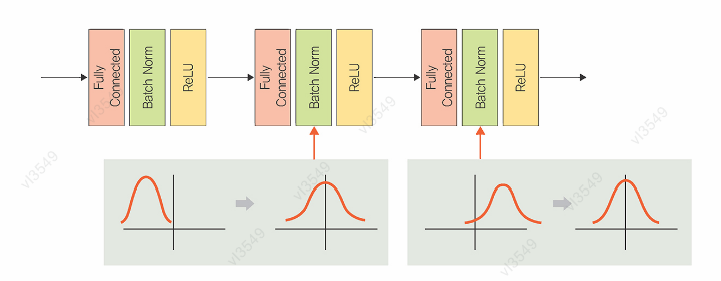

In [21]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [22]:
!pip install torchinfo
import torchinfo
from torchinfo import summary

# summary(모델객체, input_size=(배치크기, 채널, 세로, 가로))
summary(model, input_size=(100, 1, 28, 28))


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


/Users/namun/dev/A7608-2026-1-vision-dl/.venv/lib/python3.10/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Layer (type:depth-idx)                   Output Shape              Param #
FashionCNN                               [100, 10]                 --
├─Sequential: 1-1                        [100, 32, 14, 14]         --
│    └─Conv2d: 2-1                       [100, 32, 28, 28]         320
│    └─BatchNorm2d: 2-2                  [100, 32, 28, 28]         64
│    └─ReLU: 2-3                         [100, 32, 28, 28]         --
│    └─MaxPool2d: 2-4                    [100, 32, 14, 14]         --
├─Sequential: 1-2                        [100, 64, 6, 6]           --
│    └─Conv2d: 2-5                       [100, 64, 12, 12]         18,496
│    └─BatchNorm2d: 2-6                  [100, 64, 12, 12]         128
│    └─ReLU: 2-7                         [100, 64, 12, 12]         --
│    └─MaxPool2d: 2-8                    [100, 64, 6, 6]           --
├─Linear: 1-3                            [100, 600]                1,383,000
├─Dropout2d: 1-4                         [100, 600]                --
├─

In [ ]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        #train = Variable(images.view(100, 1, 28, 28))
        #labels = Variable(labels)

        train = images.view(100, 1, 28, 28)
        outputs = model(train)

        loss = criterion(outputs, labels)   # 오차 계산
        optimizer.zero_grad()               # 초기화
        loss.backward()                     # 역전파(기울기 계산)
        optimizer.step()                    # 기울기 계산값을 가지고 가중치 업데이트
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                #test = Variable(images.view(100, 1, 28, 28))
                test = images.view(100, 1, 28, 28)
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.23541347682476044, Accuracy: 87.25%
Iteration: 1000, Loss: 0.25871729850769043, Accuracy: 88.54000091552734%


In [ ]:
import matplotlib.pyplot as plt

# 1. GPU에 남아있을 수 있는 텐서 데이터를 안전하게 CPU 수치로 변환합니다.
# (hasattr를 사용해 .cpu()나 .item()이 있는 데이터만 안전하게 가공합니다.)
cleaned_loss = []
for loss in loss_list:
    if hasattr(loss, 'cpu'):
        cleaned_loss.append(loss.cpu().item())
    elif hasattr(loss, 'item'):
        cleaned_loss.append(loss.item())
    else:
        cleaned_loss.append(loss)

cleaned_accuracy = []
for acc in accuracy_list:
    if hasattr(acc, 'cpu'):
        cleaned_accuracy.append(acc.cpu().item())
    elif hasattr(acc, 'item'):
        cleaned_accuracy.append(acc.item())
    else:
        cleaned_accuracy.append(acc)

# 2. 가로로 긴 1행 2열짜리 서브플롯(Subplot)을 만들어 나란히 배치합니다.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- [왼쪽 그래프] 손실(Loss) 변화 추이 ---
ax1.plot(iteration_list, cleaned_loss, color='tomato', label='Training Loss', linewidth=2)
ax1.set_title('Training Loss over Iterations', fontsize=14, pad=15)
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# --- [오른쪽 그래프] 정확도(Accuracy) 변화 추이 ---
ax2.plot(iteration_list, cleaned_accuracy, color='royalblue', label='Test Accuracy', linewidth=2)
ax2.set_title('Test Accuracy over Iterations', fontsize=14, pad=15)
ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

# 3. 그래프 여백 자동 조절 및 출력
plt.tight_layout()
plt.show()

In [ ]:
# 마찬가지로 loss.data로 텐서 형태로 저장해 두었기 때문에 matploblib이 바로 접근할 수 없기 때문에
# 아래와 같이 cpu로 보낸 다음에 item으로 내용물만 리스트에 저장하는 절차를 미리 거쳐놔야 함

cnn_loss_list = [loss.cpu().item() for loss in loss_list]
cnn_accuracy_list = [acc.cpu().item() if hasattr(acc, 'cpu') else acc for acc in accuracy_list]
cnn_iteration_list = iteration_list[:]

In [ ]:
import matplotlib.pyplot as plt

# 1행 2열 구조로 도화지 준비 (가로 15인치, 세로 6인치)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- [왼쪽 그래프] 손실(Loss) 비교 (DNN vs CNN) ---
# dnn_loss_list와 cnn_loss_list를 바로 입력하여 겹쳐 그립니다.
ax1.plot(dnn_iteration_list, dnn_loss_list, label='DNN Loss', color='gray', linestyle='--', linewidth=1.5)
ax1.plot(cnn_iteration_list, cnn_loss_list, label='CNN Loss', color='tomato', linestyle='-', linewidth=2)

ax1.set_title('Loss Comparison (DNN vs CNN)', fontsize=14, pad=15)
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11)


# --- [오른쪽 그래프] 정확도(Accuracy) 비교 (DNN vs CNN) ---
# dnn_accuracy_list와 cnn_accuracy_list를 바로 입력하여 겹쳐 그립니다.
ax2.plot(dnn_iteration_list, dnn_accuracy_list, label='DNN Accuracy', color='darkgray', linestyle='--', linewidth=1.5)
ax2.plot(cnn_iteration_list, cnn_accuracy_list, label='CNN Accuracy', color='royalblue', linestyle='-', linewidth=2)

ax2.set_title('Accuracy Comparison (DNN vs CNN)', fontsize=14, pad=15)
ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11)

# 레이아웃 간격 정렬 후 화면 출력
plt.tight_layout()
plt.show()